# DATA INSPECTION

In [186]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import roc_curve, roc_auc_score

In [187]:
train_df = pd.read_csv("churn_train.csv")
train_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [188]:
test_df = pd.read_csv("churn_test.csv")
test_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [189]:
train_df.shape

(440833, 12)

In [190]:
test_df.shape

(64374, 12)

In [191]:
train_df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [192]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [193]:
train_df.describe(include="all")

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832,440832.000000,440832.000000,440832.000000,440832.000000,440832,440832,440832.000000,440832.000000,440832.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,NaN,NaN,NaN
top,NaN,NaN,Male,NaN,NaN,NaN,NaN,Standard,Annual,NaN,NaN,NaN
freq,NaN,NaN,250252,NaN,NaN,NaN,NaN,149128,177198,NaN,NaN,NaN
mean,225398.667955,39.373153,NaN,31.256336,15.807494,3.604437,12.965722,NaN,NaN,631.616223,14.480868,0.460409
std,129531.918550,12.442369,NaN,17.255727,8.586242,3.070218,8.258063,NaN,NaN,240.803001,8.596208,0.498431
min,2.000000,18.000000,NaN,1.000000,1.000000,0.000000,0.000000,NaN,NaN,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,NaN,16.000000,9.000000,1.000000,6.000000,NaN,NaN,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,NaN,32.000000,16.000000,3.000000,12.000000,NaN,NaN,661.000000,14.000000,0.000000
75%,337739.250000,48.000000,NaN,46.000000,23.000000,6.000000,19.000000,NaN,NaN,830.000000,22.000000,1.000000


# DATA UNDERSTANDING AND DATA QUALITY AUDIT

In [194]:
train_df.dtypes

CustomerID           float64
Age                  float64
Gender                object
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object

In [195]:
num = ["Age", "Tenure", "Usage Frequency", "Support Calls", "Payment Delay", "Total Spend", "Last Interaction", "Churn"]
cat = ["Gender", "Subscription Type", "Contract Length"]

In [196]:
test_df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [197]:
train_df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [198]:
train_df = train_df.dropna()
train_df.shape

(440832, 12)

In [199]:
test_df.duplicated().sum()

np.int64(0)

In [200]:
train_df.duplicated().sum()

np.int64(0)

In [201]:
for col in cat:
    print(f"\n{col}")
    print(train_df[col].unique())


Gender
['Female' 'Male']

Subscription Type
['Standard' 'Basic' 'Premium']

Contract Length
['Annual' 'Monthly' 'Quarterly']


In [202]:
for col in cat:
    print(f"\n{train_df[col].value_counts()}")


Gender
Male      250252
Female    190580
Name: count, dtype: int64

Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64


In [203]:
train_df[num].agg(["min", "max"])

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
min,18.0,1.0,1.0,0.0,0.0,100.0,1.0,0.0
max,65.0,60.0,30.0,10.0,30.0,1000.0,30.0,1.0


In [204]:
train_df[num].describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.460409
std,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.498431
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,0.000000
75%,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [205]:
(train_df[num] < 0).sum()

Age                 0
Tenure              0
Usage Frequency     0
Support Calls       0
Payment Delay       0
Total Spend         0
Last Interaction    0
Churn               0
dtype: int64

In [206]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (440832, 12)
Test shape: (64374, 12)


In [207]:
print("Columns in train:", train_df.columns.tolist())
print("Columns in test:", test_df.columns.tolist())

Columns in train: ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']
Columns in test: ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


In [208]:
train_df.columns.equals(test_df.columns)

True

# EXPLORATORY DATA ANALYSIS

In [209]:
train_df["Churn"].value_counts()

Churn
0.0    237869
1.0    202963
Name: count, dtype: int64

In [210]:
train_df["Churn"].value_counts(normalize=True) * 100

Churn
0.0    53.959105
1.0    46.040895
Name: proportion, dtype: float64

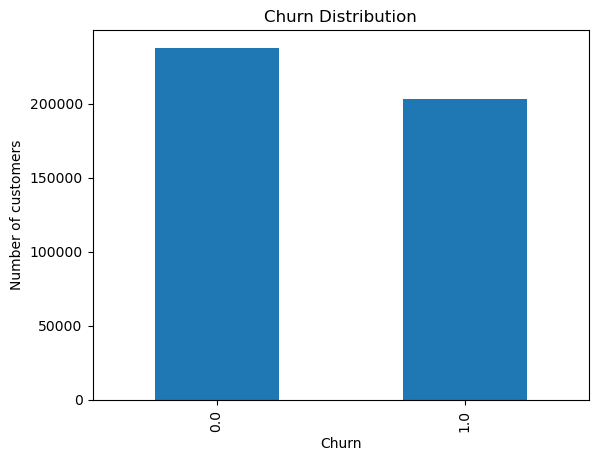

In [211]:
train_df["Churn"].value_counts().plot(kind = "bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of customers")

plt.show()

In [212]:
train_df[num].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,440832.0,39.373153,12.442369,18.0,29.0,39.0,48.0,65.0
Tenure,440832.0,31.256336,17.255727,1.0,16.0,32.0,46.0,60.0
Usage Frequency,440832.0,15.807494,8.586242,1.0,9.0,16.0,23.0,30.0
Support Calls,440832.0,3.604437,3.070218,0.0,1.0,3.0,6.0,10.0
Payment Delay,440832.0,12.965722,8.258063,0.0,6.0,12.0,19.0,30.0
Total Spend,440832.0,631.616223,240.803001,100.0,480.0,661.0,830.0,1000.0
Last Interaction,440832.0,14.480868,8.596208,1.0,7.0,14.0,22.0,30.0
Churn,440832.0,0.460409,0.498431,0.0,0.0,0.0,1.0,1.0


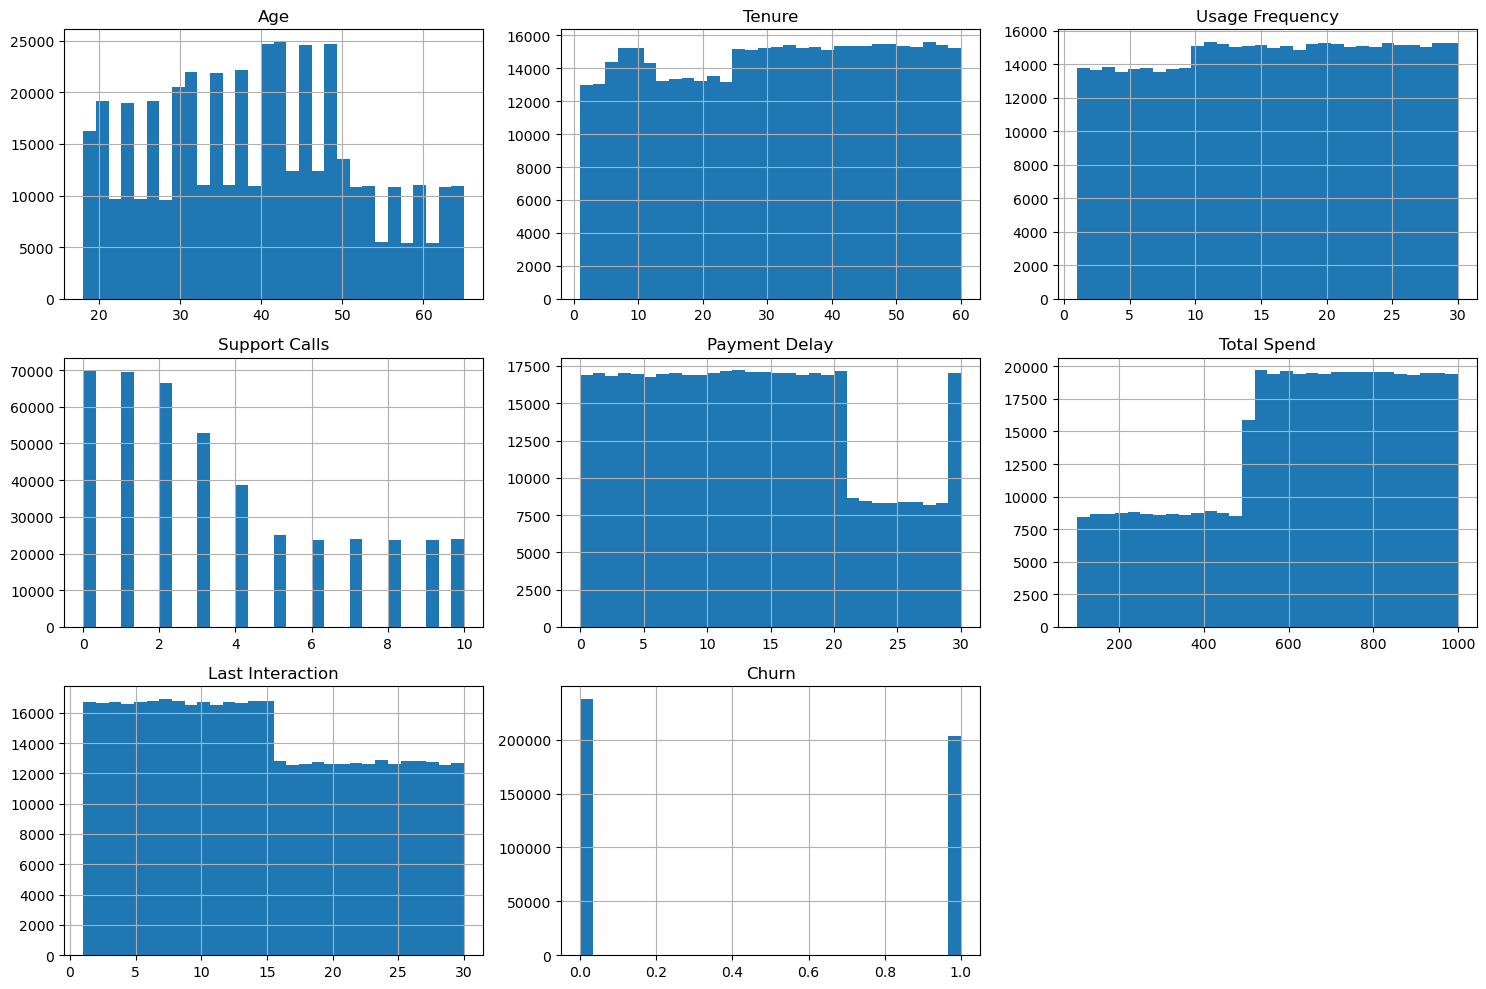

In [213]:
train_df[num].hist(figsize=(15, 10), bins=30)

plt.tight_layout()
plt.show()

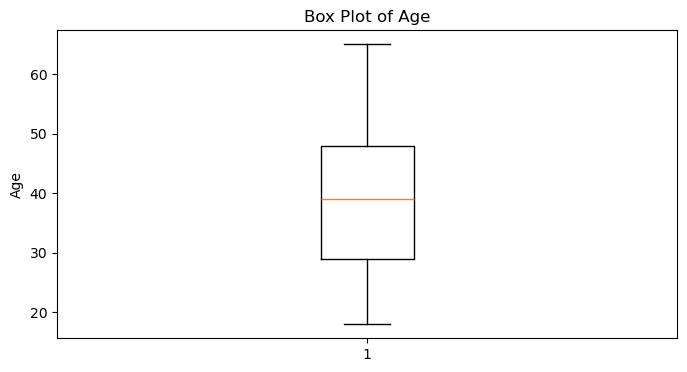

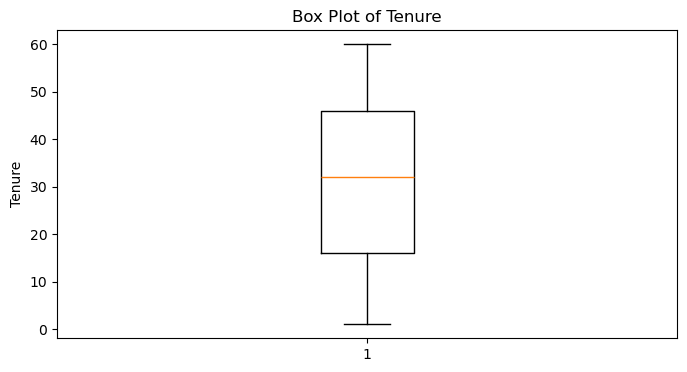

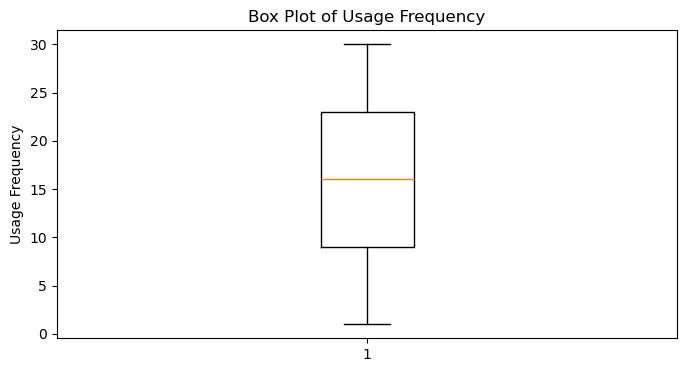

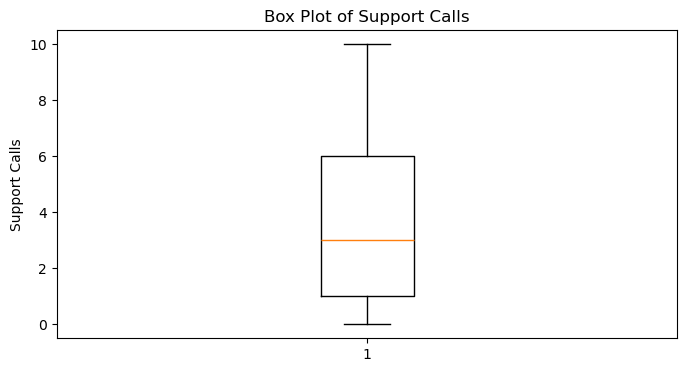

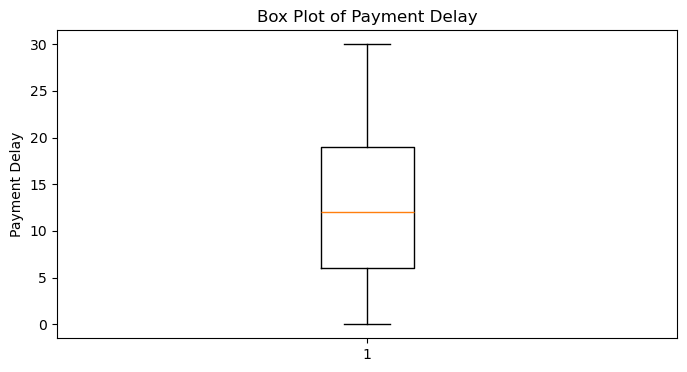

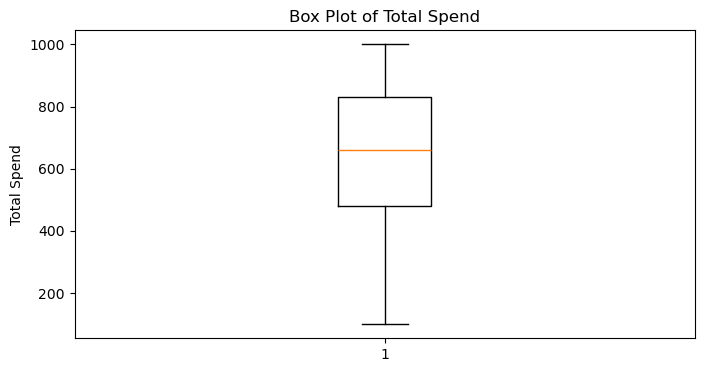

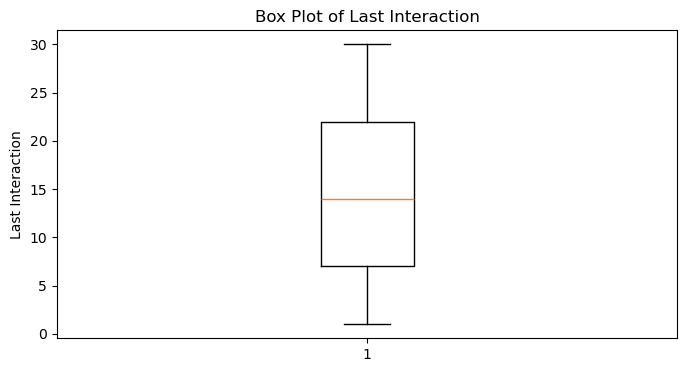

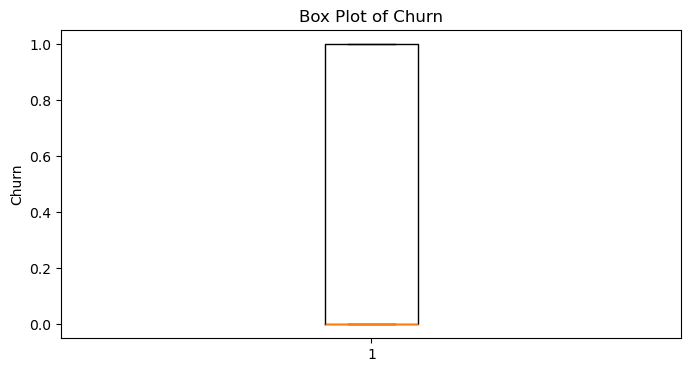

In [214]:
for col in num:
    plt.figure(figsize=(8, 4))
    plt.boxplot(train_df[col].dropna())
    plt.title(f"Box Plot of {col}")
    plt.ylabel(col)
    plt.show()

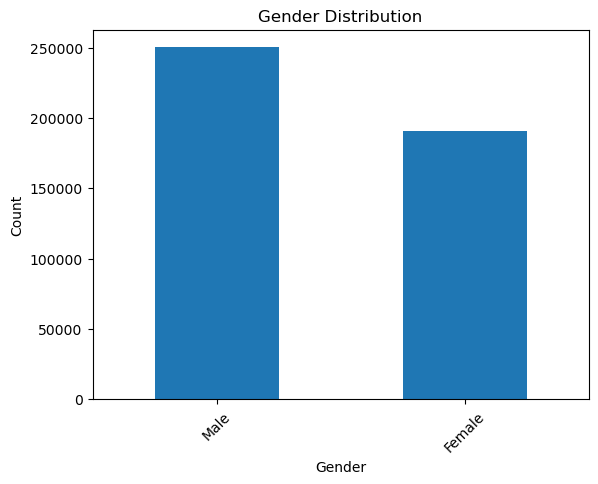

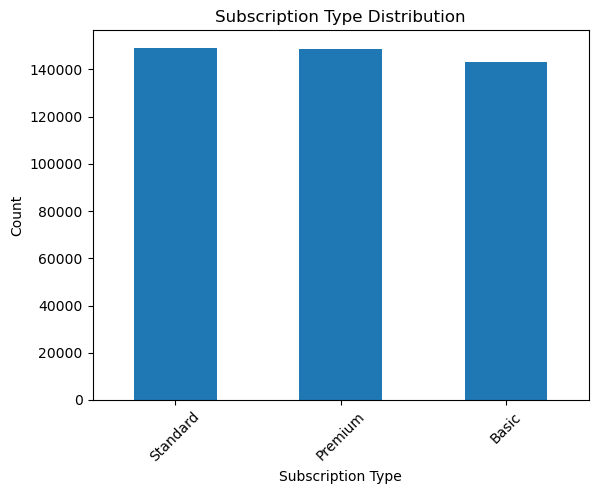

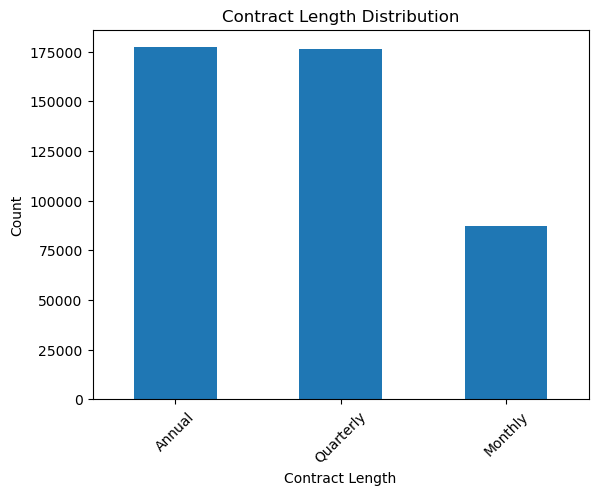

In [215]:
for col in cat:
    train_df[col].value_counts().plot(kind="bar")

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

In [216]:
train_df.groupby("Churn")[num].mean().T

Churn,0.0,1.0
Age,37.306156,41.795638
Tenure,31.940631,30.454354
Usage Frequency,16.601163,14.877327
Support Calls,2.121197,5.342767
Payment Delay,10.532604,15.817292
Total Spend,724.119008,523.204615
Last Interaction,13.013125,16.201037
Churn,0.000000,1.000000


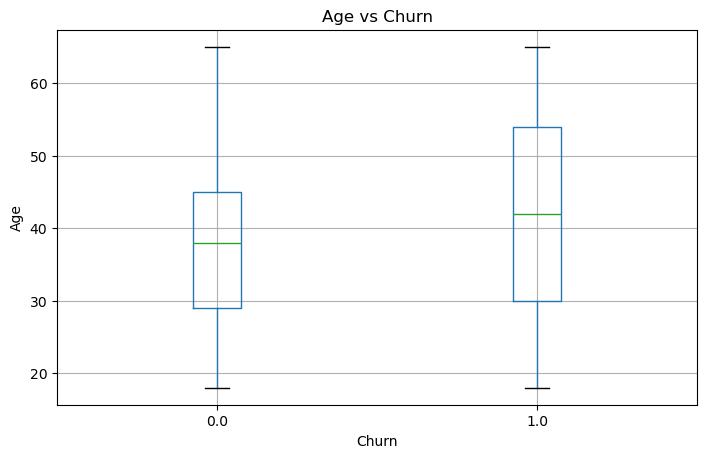

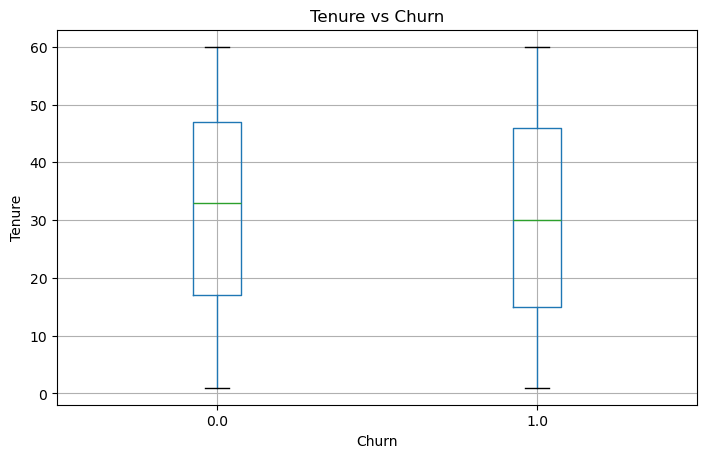

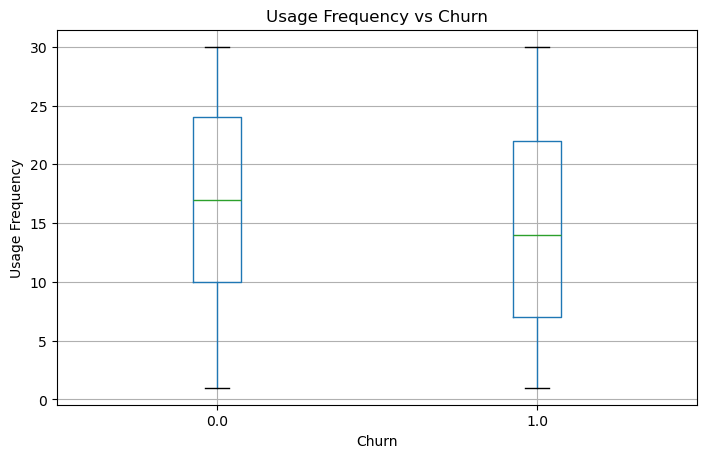

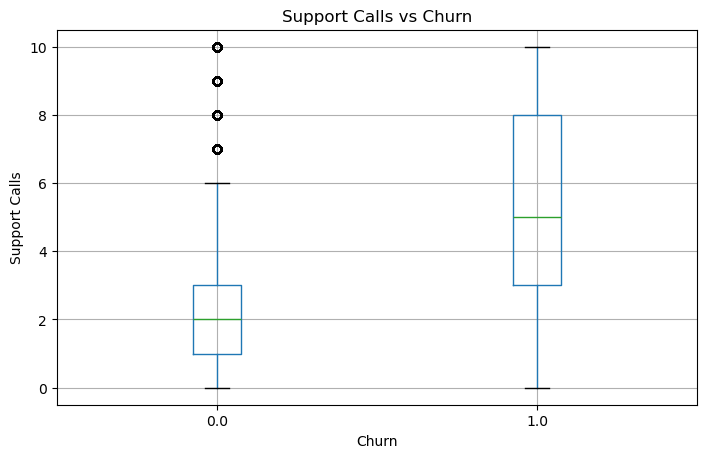

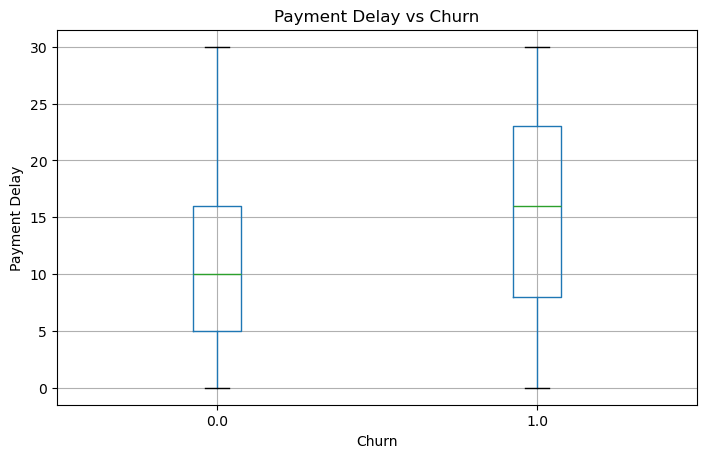

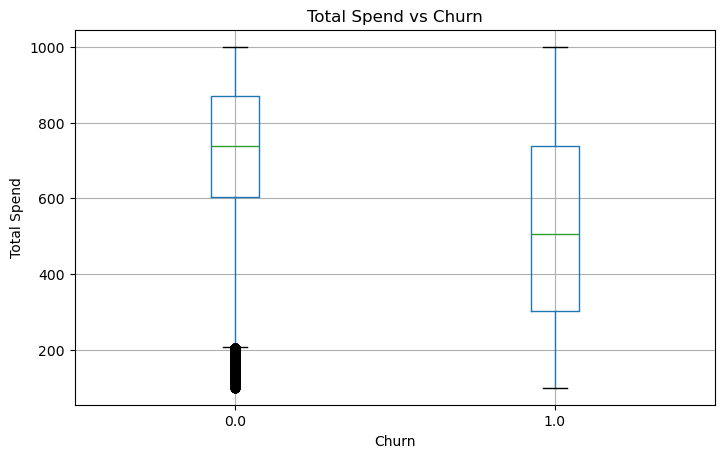

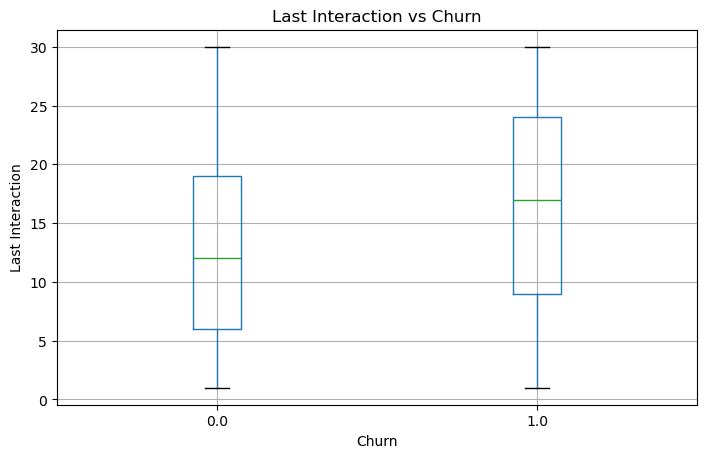

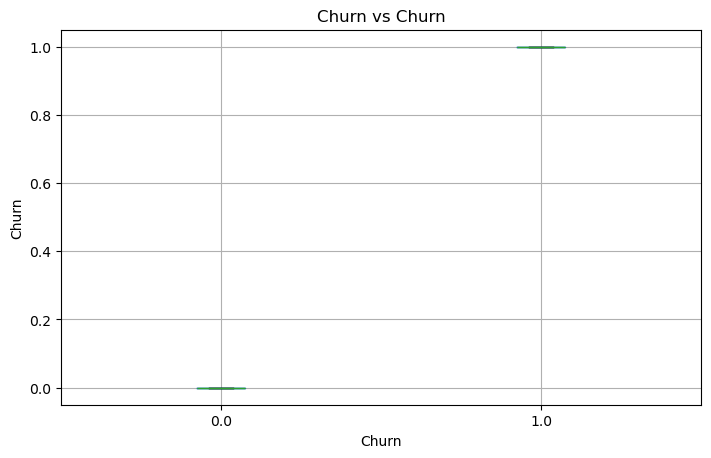

In [217]:
for col in num:
    train_df.boxplot(column=col, by="Churn", figsize=(8, 5))

    plt.title(f"{col} vs Churn")
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

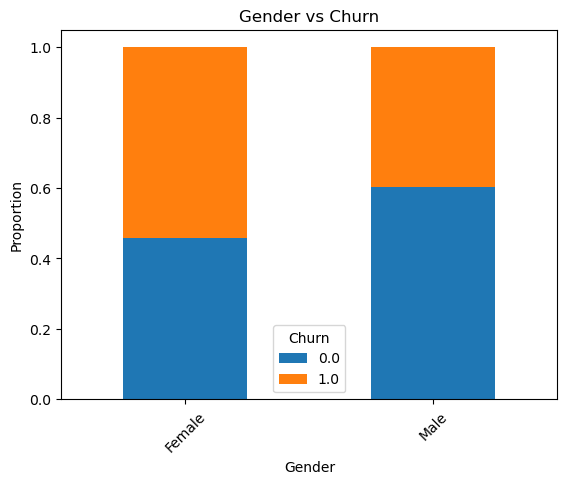

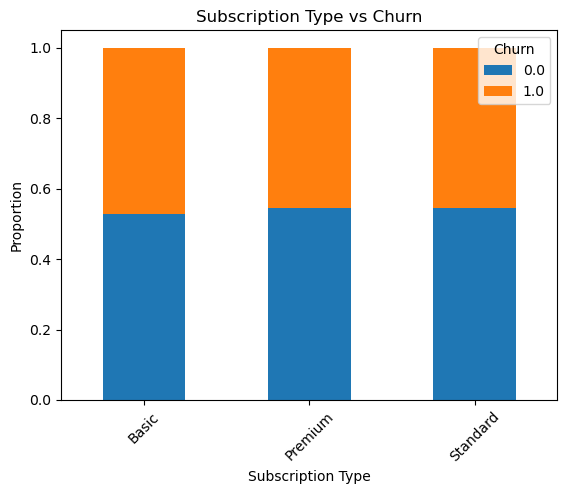

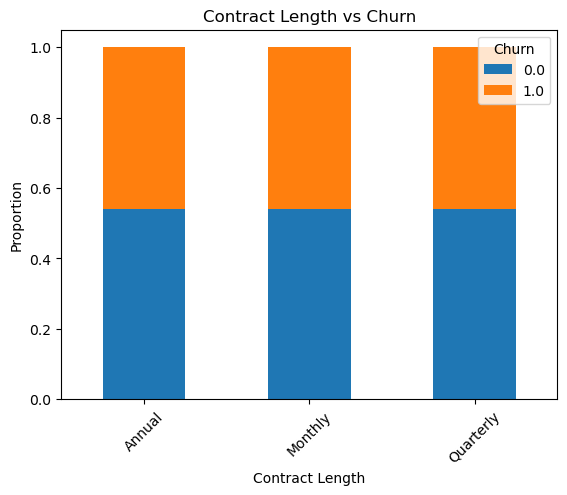

In [218]:
for col in cat:
    pd.crosstab(
        train_df[col],
        train_df["Churn"],
        normalize="index"
    ).plot(kind="bar", stacked=True)

    plt.title(f"{col} vs Churn")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.legend(title="Churn")
    plt.xticks(rotation=45)
    plt.show()

In [219]:
corr = train_df[num].corr()
corr

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
Age,1.000000,-0.011630,-0.007190,0.158451,0.061738,-0.084684,0.028980,0.179845
Tenure,-0.011630,1.000000,-0.026800,-0.027640,-0.016588,0.019006,-0.006903,-0.042931
Usage Frequency,-0.007190,-0.026800,1.000000,-0.022013,-0.014470,0.018631,-0.004662,-0.100069
Support Calls,0.158451,-0.027640,-0.022013,1.000000,0.162889,-0.221594,0.077684,0.523002
Payment Delay,0.061738,-0.016588,-0.014470,0.162889,1.000000,-0.121044,0.042708,0.318967
Total Spend,-0.084684,0.019006,0.018631,-0.221594,-0.121044,1.000000,-0.056890,-0.415866
Last Interaction,0.028980,-0.006903,-0.004662,0.077684,0.042708,-0.056890,1.000000,0.184843
Churn,0.179845,-0.042931,-0.100069,0.523002,0.318967,-0.415866,0.184843,1.000000


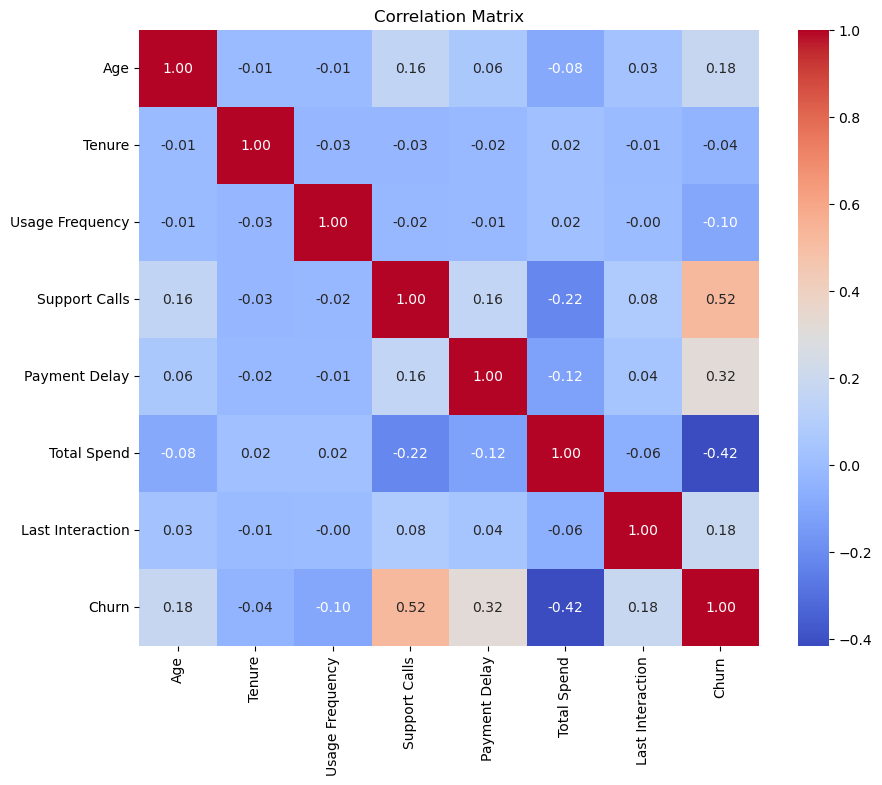

In [220]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [221]:
train_df[num].skew().sort_values()

Total Spend        -0.457174
Tenure             -0.061402
Usage Frequency    -0.043473
Churn               0.158864
Age                 0.162016
Last Interaction    0.176774
Payment Delay       0.267407
Support Calls       0.666809
dtype: float64

In [222]:
print("OUTLIER COUNT: \n")

for col in num:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((train_df[col] < lower) | (train_df[col] > upper)).sum()
    print(f"{col}: {outliers} ")

OUTLIER COUNT: 

Age: 0 
Tenure: 0 
Usage Frequency: 0 
Support Calls: 0 
Payment Delay: 0 
Total Spend: 0 
Last Interaction: 0 
Churn: 0 


# CATEGORICAL ENCODING 

In [223]:
X = train_df.drop(columns=["Churn", "CustomerID"])
y = train_df["Churn"]

In [224]:
X_test = test_df.drop(columns=["CustomerID"])

In [225]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            cat
        )
    ],
    remainder="passthrough"
)

In [226]:
X_encoded = preprocessor.fit_transform(X)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded X shape:", X_encoded.shape)
print("Encoded X_test shape:", X_test_encoded.shape)

Encoded X shape: (440832, 15)
Encoded X_test shape: (64374, 15)


# TRAIN / VALIDATION SPLIT + FEATURE SCALING 

In [227]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [228]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (352665, 10)
X_val: (88167, 10)
y_train: (352665,)
y_val: (88167,)


In [229]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True) * 100)

Training target distribution:
Churn
0.0    53.95914
1.0    46.04086
Name: proportion, dtype: float64

Validation target distribution:
Churn
0.0    53.958964
1.0    46.041036
Name: proportion, dtype: float64


In [230]:
num = ["Age", "Tenure", "Usage Frequency", "Support Calls", "Payment Delay", "Total Spend", "Last Interaction"]

In [231]:
print(X_train[num].mean())

Age                  39.383273
Tenure               31.240580
Usage Frequency      15.806814
Support Calls         3.606703
Payment Delay        12.962781
Total Spend         631.500347
Last Interaction     14.489643
dtype: float64


In [232]:
print(X_train[num].std())

Age                  12.436629
Tenure               17.258105
Usage Frequency       8.585698
Support Calls         3.068840
Payment Delay         8.259259
Total Spend         240.722385
Last Interaction      8.596240
dtype: float64


In [233]:
print(X_val[num].describe().T)

                    count        mean         std    min    25%    50%  \
Age               88167.0   39.332675   12.465294   18.0   29.0   39.0   
Tenure            88167.0   31.319360   17.246167    1.0   16.0   32.0   
Usage Frequency   88167.0   15.810212    8.588465    1.0    9.0   16.0   
Support Calls     88167.0    3.595370    3.075725    0.0    1.0    3.0   
Payment Delay     88167.0   12.977486    8.253313    0.0    6.0   13.0   
Total Spend       88167.0  632.079722  241.126002  100.0  481.0  662.0   
Last Interaction  88167.0   14.445768    8.596037    1.0    7.0   14.0   

                     75%     max  
Age                48.00    65.0  
Tenure             46.00    60.0  
Usage Frequency    23.00    30.0  
Support Calls       6.00    10.0  
Payment Delay      19.00    30.0  
Total Spend       830.72  1000.0  
Last Interaction   22.00    30.0  


# MODEL BUILDING

In [234]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat)
    ]
)

model1 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])

In [235]:
model1.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [236]:
y_pred = model1.predict(X_val)
y_pred

array([0., 0., 0., ..., 1., 0., 0.], shape=(88167,))

In [237]:
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

In [238]:
print("TRAIN ACCURACY: ", accuracy)
print("TRAIN PRECISION: ", precision)
print("TRAIN RECALL: ",recall)
print("TRAIN F1: ",f1)

TRAIN ACCURACY:  0.8404391665816008
TRAIN PRECISION:  0.8482890832217233
TRAIN RECALL:  0.7957529623334072
TRAIN F1:  0.8211816148057759


In [239]:
train_pred = model1.predict(X_train)
val_pred = model1.predict(X_val)
train_accuracy = accuracy_score(y_train, train_pred)
val_accuracy = accuracy_score(y_val, val_pred)

In [240]:
print("TRAIN ACCURACY:", train_accuracy)
print("VALIDATION ACCURACY:", val_accuracy)
print("DIFFERENCE:", train_accuracy - val_accuracy)

TRAIN ACCURACY: 0.8390880864276297
VALIDATION ACCURACY: 0.8404391665816008
DIFFERENCE: -0.0013510801539711181


In [241]:
X_test_final = test_df.drop(columns=["Churn", "CustomerID"])
y_test = test_df["Churn"]

test_pred = model1.predict(X_test_final)

In [242]:
print("TEST ACCURACY:", accuracy_score(y_test, test_pred))
print("TEST PRECISION:", precision_score(y_test, test_pred))
print("TEST RECALL:", recall_score(y_test, test_pred))
print("TEST F1:", f1_score(y_test, test_pred))

TEST ACCURACY: 0.6361574548730854
TEST PRECISION: 0.5752666425393311
TEST RECALL: 0.8861705965303512
TEST F1: 0.6976480004130845


# HYPER PARAMETER TUNING

In [243]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["lbfgs"]
}

logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

logistic_grid.fit(X_train, y_train)

print("Best Parameters:", logistic_grid.best_params_)
print("Best CV ROC-AUC:", logistic_grid.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters: {'model__C': 0.01, 'model__solver': 'lbfgs'}
Best CV ROC-AUC: 0.9130904723633493


In [244]:
best_model = logistic_grid.best_estimator_

print("VALIDATION ACCURACY:", accuracy_score(y_val, best_model.predict(X_val)))
print("TEST ACCURACY:", accuracy_score(y_test, best_model.predict(X_test)))

VALIDATION ACCURACY: 0.840450508693729
TEST ACCURACY: 0.6363438655357753


In [245]:
y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

In [246]:
print("TEST PRECISION:", precision_score(y_test, y_test_pred))
print("TEST RECALL:", recall_score(y_test, y_test_pred))
print("TEST F1:", f1_score(y_test, y_test_pred))
print("TEST ROC-AUC:", roc_auc_score(y_test, y_test_prob))

TEST PRECISION: 0.5753302278093293
TEST RECALL: 0.8870232512379891
TEST F1: 0.6979588677005651
TEST ROC-AUC: 0.7496207791022846


# CONFUSION MATRIC - ROC CURVE - FEATURE IMPORTANCE

In [247]:
y_test_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred)

print(cm)

[[13916 19965]
 [ 3445 27048]]


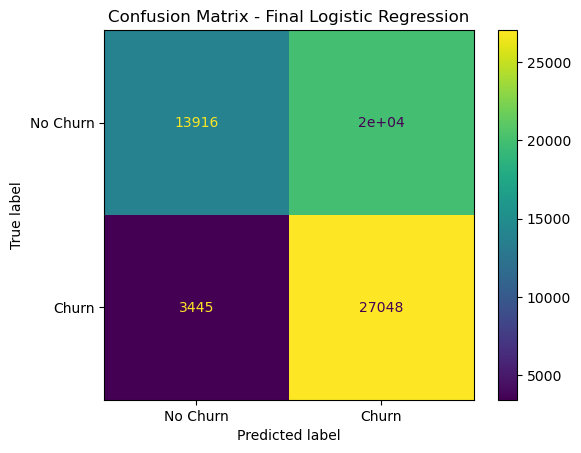

In [248]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Final Logistic Regression")
plt.show()

In [250]:
y_test_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
roc_auc = roc_auc_score(y_test, y_test_prob)

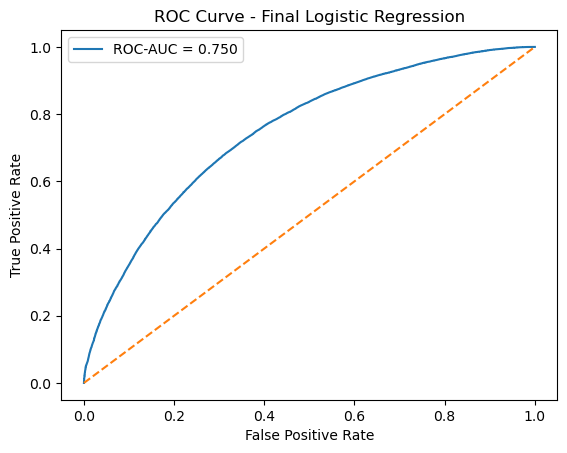

In [251]:
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Logistic Regression")
plt.legend()
plt.show()

In [252]:
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7496207791022846


In [253]:
preprocessor_fitted = best_model.named_steps["preprocessor"]
logistic_model = best_model.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()
coefficients = logistic_model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
3,num__Support Calls,1.635580,1.635580
13,cat__Contract Length_Monthly,-1.524647,1.524647
5,num__Total Spend,-1.202594,1.202594
4,num__Payment Delay,0.876610,0.876610
12,cat__Contract Length_Annual,0.692600,0.692600
14,cat__Contract Length_Quarterly,0.690588,0.690588
6,num__Last Interaction,0.601450,0.601450
8,cat__Gender_Male,-0.494687,0.494687
7,cat__Gender_Female,0.353228,0.353228
2,num__Usage Frequency,-0.348912,0.348912


# SAVING THE MODEL 

In [254]:
import joblib

In [255]:
joblib.dump(best_model, "final_churn_model.pkl")

['final_churn_model.pkl']